# Градиентный спуск: пять вариаций с нуля

Пять оптимизаторов, написанных на голом NumPy и проверенных на одной задаче: Vanilla, SGD, SAG, Momentum и Adam. Все они универсальные — градиенты конкретной функции потерь считаются не внутри оптимизатора, а в модели, поэтому функцию потерь можно менять, не трогая код оптимизации.

Поверх них — своя линейная регрессия с тремя способами обучения: градиентным спуском, аналитическим решением через нормальное уравнение и через усечённое SVD (последнее нужно, когда $X^\top X$ необратима из-за мультиколлинеарности). Дополнительно: расписание шага с затуханием по времени, L2-регуляризация и альтернативные функции потерь LogCosh и Huber с выведенными градиентами.

Данные для проверки — объявления о продаже автомобилей с немецкого eBay, предсказывается цена.

---


Реализуем обучение линейной регрессии с помощью различных модификаций градиентного спуска. В файле `descents.py` напишем несколько классов для различных вариаций градиентного спуска, а именно:
* `VanillaGradientDescent`
* `StochasticGradientDescent`
* `StochasticAverageGradient`
* `MomentumDescent`
* `Adam`

В файле `linear_regression.py` реализуем класс `LinearRegression` для обучения линейной регрессии (и, разумеется, предсказания целевой переменной на основе обученной модели).

## 1. Реализация градиентного спуска 

Напишем собственные реализации различных подходов к градиентному спуску в файле `descents.py`.

**Все методы постараемся по максимуму векторизовать**

### Flashbacks 

Основное свойство антиградиента &ndash; он указывает в сторону *наискорейшего* убывания функции в данной точке. Соответственно, будет логично стартовать из некоторой точки, сдвинуться в сторону антиградиента,
пересчитать антиградиент и снова сдвинуться в его сторону и т.д. Запишем это более формально.

Пусть $w_0$ &ndash; начальный набор параметров (например, нулевой или сгенерированный из некоторого
случайного распределения). Тогда ванильный градиентный спуск состоит в повторении следующих шагов до сходимости:

$$
    w_{k + 1} = w_{k} - \eta_{k} \nabla_{w} Q(w_{k}).
$$

Здесь $\eta_{k}$ обозначает длину шага на $k$-ой итерации (learning rate), а $Q(w)$ - функцию потерь (loss function).

### Градиент функции потерь MSE


### 1.0. Градиент MSE в матричном виде.

Функция потерь MSE записывается как:

$$
    Q(w) = \frac{1}{\ell} \sum \limits_{i = 1}^\ell (y_i - \langle x_i, w \rangle)^2 = \frac{1}{\ell} \| X w - y \|^2
$$

где $\ell$ – количество объектов в выборке, $X \in \mathbb{R}^{\ell \times d}$ – матрица "объект-признак", а $y \in \mathbb{R}^\ell$ – целевая переменная. Через $x_i$ обозначается $i$-ая строчка матрицы $X$, отвечающая за $i$-й объект выборки.

Выпишем градиент для функции потерь MSE в матричном виде.

**Решение:**

$L(w) = \frac{1}{N} \|Xw - y\|_2^2 = \frac{1}{N} (Xw - y)^\top (Xw - y)$


$dL(w) = \frac{2}{N} \langle Xw - y,\, X\,dw \rangle = \frac{2}{N} \langle X^\top (Xw - y),\, dw \rangle$


$\nabla_w L(w) = \frac{2}{N} X^\top (Xw - y)$ 

### 1.1. Learning Rate Schedules 

Уделим больше внимания **абстрактному** классу `LearningRateSchedule` в файле `descents.py`. С помощью него мы на каждой итерации градиентного спуска будем получать соответствующий `learning_rate` $\eta_k$.

В файле уже был реализован класс `ConstantLR`, который на каждой итерации возвращает один и тот же заранее заданный шаг. Сейчас надо реализовать `TimeDecayLR`, который будем использовать для обучения линейной регрессии. Формула очередного шага выглядит следующим образом:
$$
    \eta_{k} = \lambda \left(\dfrac{s_0}{s_0 + k}\right)^p
$$

На практике достаточно настроить параметр $\lambda$, а остальным выставить параметры по умолчанию: $s_0 = 1, \, p = 0.5.$

**Замечание**

Все реализуемые классы спуска в задании - это *универсальные* оптимизаторы. Они не считают градиенты конкретной функции потерь внутри себя.

Для вычисления градиента они всегда обращаются к модели, с которой работают:

```
gradient = self.model.compute_gradients(X_batch, y_batch)
```

Чтобы это работало, в `linear_regression.py` пропишем:

* `compute_gradients(X, y)` для MSE (в дальнейшем, в пункте 7, сюда добавляется член L2-регуляризации),
* `compute_loss(X, y)` для MSE (аналогично с учётом L2 при необходимости).

Реализуем эти MSE-версии в начале 2.1 (используя формулы из п. 1.0), а затем вернемся к 1.2–1.6 - тогда код оптимизаторов менять не придётся. В 8 пункте мы просто расширим обе функции под `LogCosh` и `Huber`, переключая их через `self.loss_function`.

Такой подход позволяет свободно менять функцию потерь, не переписывая алгоритмы оптимизации, что приятно)

### Примечание 1.1. Родительский класс BaseDescent.

В файле `descents.py` также приведен класс `BaseDescent` – родительский класс для модификаций градиентного спуска, от которого будут наследоваться другие классы (`VanillaGradientDescent`, `StochasticGradientDescent`, `MomentumDescent` и `Adam`). 

С помощью атрибутов `self.iteration` (отвечает за номер итерации алгоритма спуска) и `self.lr_schedule` мы и будем получать `learning_rate` на соответствующей итерации алгоритма. Функция `update_weights` должна обновлять веса модели `self.model.w`, а также возвращать величину обновления $w_{k + 1} - w_k$

### 1.2. Полный градиентный спуск VanillaGradientDescent.

Реализуем полный градиентный спуск в классе `VanillaGradientDescent` в файле `descents.py`. Не забывая, что шаг классического градиентного спуска выглядит следующим образом:

$$
    w_{k + 1} = w_{k} - \eta_{k} \nabla_{w} Q(w_{k}).
$$

**Важно**: Здесь и далее функция `update_weights` будет возвращать разницу между $w_{k + 1}$ и $w_{k}$: $\quad w_{k + 1} - w_{k} = -\eta_{k} \nabla_{w} Q(w_{k})$. Кроме того, соответственно своему названию, она должна обновлять веса модели `model.w`.

### База про SGD (стохастических градиентный спуск)

Как правило, в задачах машинного обучения функционал $Q(w)$ представим в виде суммы $\ell$ функций:

$$
    Q(w)
    =
    \frac{1}{\ell}
    \sum_{i = 1}^{\ell}
        q_i(w).
$$

Но в моей работе отдельные функции $q_i(w)$ соответствуют ошибкам на отдельных объектах.

Проблема метода градиентного спуска состоит в том, что на каждом шаге необходимо вычислять градиент всей суммы (далее: "полный градиент"):

$$
    \nabla_w Q(w)
    =
    \frac{1}{\ell}
    \sum_{i = 1}^{\ell}
        \nabla_w q_i(w).
$$

Это может быть очень трудоёмко при больших размерах выборки. В то же время точное вычисление градиента может быть не так уж необходимо &ndash; как правило, мы делаем не очень большие шаги в сторону антиградиента, и наличие в нём неточностей не должно сильно сказаться на общей траектории.

Оценить градиент суммы функций можно средним градиентов случайно взятого подмножества функций:

$$
    \nabla_{w} Q(w_{k}) \approx \dfrac{1}{|B|}\sum\limits_{i \in B}\nabla_{w} q_{i}(w_{k}),
$$
где $B$ - это случайно выбранное подмножество индексов, называемое **батчом**.

Оценка $\frac{1}{|B|} \sum \limits_{i \in B} \nabla_w q_i(w_k)$ называется **стохастическим градиентом** функции потерь, а получившийся метод называют методом **стохастического градиентного спуска** или просто SGD.

### 1.3. Стохастический градиентный спуск StochasticGradientDescent.

Реализуем стохастический градиентный спуск в классе `StochasticGradientDescent`. Для оценки градиента используем формулу выше (среднее градиентов случайно выбранного батча объектов). Шаг оптимизации:

$$
    w_{k + 1} = w_{k} - \eta_{k} \dfrac{1}{|B|}\sum\limits_{i \in B}\nabla_{w} q_{i}(w_{k}).
$$

Размер батча будет являться **гиперпараметром** метода и передаваться в конструктор класса `__init__(...)`. Вообще говоря, семплировать индексы батча объектов $B$ можно с повторениями (через np.random.randint) - это допустимо и даёт несмещённую оценку градиента. А также можно без повторений (np.random.choice(..., replace=False) или через пермутацию по эпохам).

### База про метод инерции (метод моментов)

Может оказаться, что направление антиградиента сильно меняется от шага к шагу. Например, если линии уровня функционала сильно вытянуты, то из-за ортогональности градиента линиям уровня он будет менять направление на почти противоположное на каждом шаге. Такие осцилляции будут вносить сильный шум в движение, и процесс оптимизации займёт много итераций. Чтобы избежать этого, можно усреднять векторы антиградиента с нескольких предыдущих шагов &ndash; в этом случае шум уменьшится, и такой средний вектор будет указывать в сторону общего направления движения. Для этого введем вектор инерции:

\begin{align}
    &h_0 = 0, \\
    &h_{k + 1} = \alpha h_{k} + \eta_k \nabla_w Q(w_{k})
\end{align}

Здесь $\alpha$ &ndash; параметр метода, определяющей скорость затухания градиентов с предыдущих шагов. Разумеется, вместо вектора градиента может быть использована его аппроксимация (например, в случае **стохастического градиентного спуска**). Чтобы сделать шаг градиентного спуска, просто сдвинем предыдущую точку на вектор инерции:

$$
    w_{k + 1} = w_{k} - h_{k + 1}.
$$

Заметим, что если по какой-то координате градиент постоянно меняет знак, то в результате усреднения градиентов в векторе инерции эта координата окажется близкой к нулю. Если же по координате знак градиента всегда одинаковый, то величина соответствующей координаты в векторе инерции будет большой, и мы будем делать большие шаги в соответствующем направлении.

### 1.4 Stochastic Average Gradient 

Держим память последних индивидуальных градиентов $g_i$ по всем объектам и их среднее $\bar g = \frac{1}{\ell}\sum_i g_i$. На каждом шаге выбираем индекс(ы) $j$ (мини-батч), заново считаем $g_j^{new}(w_k)$, обновляем среднее:
$$
\bar g \leftarrow \bar g + \frac{1}{\ell}\bigl(g_j^{new} - g_j^{old}\bigr),\qquad
w_{k+1} = w_k - \eta_k, \bar g.
$$
Инициализация: $g_i=0 \Rightarrow \bar g=0$.

Так получаем шаг почти как у полного градиента, но считаем градиент лишь на одном (или нескольких) объекте за итерацию.

Реализуем таким образом класс `SAG` в `descents.py` с хранением `grad_memory` и `avg_grad`. Уточнение: чтобы получить пер-объектный градиент, можно вызывать `compute_gradients` на срезе из одного объекта `X[j:j+1]`.

### 1.5 Метод Momentum - MomentumDescent.

Реализуем градиентный спуск с методом инерции в классе `MomentumDescent`. Где шаг оптимизации:

\begin{align}
    &h_0 = 0, \\
    &h_{k + 1} = \alpha h_{k} + \eta_k \nabla_w Q(w_{k}) \\
    &w_{k + 1} = w_{k} - h_{k + 1}.
\end{align}

$\alpha$ являеться гиперпараметром метода, зафиксируем её так: $\alpha = 0.9$.

### Напоминание про AdaGrad, RMSprop и Adam

Градиентный спуск очень чувствителен к выбору длины шага. Если шаг большой, то есть риск, что мы будем перескакивать через точку минимума; если же шаг маленький, то для нахождения минимума потребуется много итераций. При этом нет способов заранее определить правильный размер шага &ndash; к тому же, схемы с постепенным уменьшением шага по мере итераций могут тоже плохо работать.

В методе AdaGrad будем стараться сделать свою длину шага для каждой компоненты вектора параметров. Идея проста: мы "копим" сумму квадратов градиентов и делим очередной градиент на корень из этой суммы. Таким образом, обновление весов с большими градиентами будет тормозиться, а с маленькими наоборот получать большие шаги. Формула обновлени будет выглядеть так:

\begin{align}
    &G_{kj} = G_{k-1,j} + (\nabla_w Q(w_{k - 1}))_j^2; \\
    &w_{jk} = w_{j,k-1} - \frac{\eta_t}{\sqrt{G_{kj}} + \varepsilon} (\nabla_w Q(w_{k - 1}))_j.
\end{align}

Здесь $\varepsilon$ небольшая константа, которая предотвращает деление на ноль.

В данном методе можно зафиксировать длину шага (например, $\eta_k = 0.01$) и не подбирать её в процессе обучения. Отмечу, что данный метод подходит для разреженных задач, в которых у каждого объекта большинство признаков равны нулю. Для признаков, у которых ненулевые значения встречаются редко, будут делаться большие шаги; если же какой-то признак часто является ненулевым, то шаги по нему будут небольшими.

Также у метода AdaGrad есть большой недостаток: переменная $G_{kj}$ монотонно растёт, из-за чего шаги становятся всё медленнее и могут остановиться ещё до того, как достигнут минимум функционала. Проблема решается в методе RMSprop, где используется экспоненциальное затухание градиентов:

$$
    G_{kj} = \alpha G_{k-1,j} + (1 - \alpha) (\nabla_w Q(w^{(k-1)}))_j^2.
$$

В этом случае размер шага по координате зависит в основном от того, насколько
быстро мы двигались по ней на последних итерациях.

Можно объединить идеи описанных выше методов: накапливать градиенты со всех прошлых шагов для
избежания осцилляций (метод инерции), а также делать адаптивную длину шага по каждому параметру (`RMSProp`). Таким образом, мы получим метод `Adam` с той лишь разницей, что в методе `Adam` дополнительно делается нормировка накопленных градиентов и квадратов градиентов для устранения смещения.

### 1.6. Метод Adam (Adaptive Moment Estimation).

Реализуем градиентный спуск с методом Adam в классе `Adam`. Шаг оптимизации:

\begin{align}
    &m_0 = 0, \quad v_0 = 0; \\ \\
    &m_{k + 1} = \beta_1 m_k + (1 - \beta_1) \nabla_w Q(w_{k}); \\ \\
    &v_{k + 1} = \beta_2 v_k + (1 - \beta_2) \left(\nabla_w Q(w_{k})\right)^2; \\ \\
    &\widehat{m}_{k} = \dfrac{m_k}{1 - \beta_1^{k}}, \quad \widehat{v}_{k} = \dfrac{v_k}{1 - \beta_2^{k}}; \\ \\
    &w_{k + 1} = w_{k} - \dfrac{\eta_k}{\sqrt{\widehat{v}_{k + 1}} + \varepsilon} \widehat{m}_{k + 1}.
\end{align}

$\beta_1 = 0.9, \beta_2 = 0.999$ и $\varepsilon = 10^{-8}$ будут зафиксированы.

## 2. Линейная регресия 

### 2.1. Решение методом градиентного спуска 

В этой части пропишем свою реализацию линейной регресии, обучаемой с использованием градиентного спуска, в файле `linear_regression.py` - **LinearRegressionModel**. По сути линейная регрессия будет оберткой, которая запускает обучение.

Необходимые условия для ускорения, простоты чтения и корректности решения:

* Все вычисления должны быть векторизованы;
* Циклы средствами python используются только для итераций градиентного спуска;
* В качестве критерия останова необходимо использовать (одновременно):
    * Квадрат евклидовой нормы разности весов на двух соседних итерациях меньше `tolerance`;
    * Разность весов содержит наны;
    * Достижение максимального числа итераций `max_iter`.
* Считаем, что все данные, которые поступают на вход имеют столбец единичек последним столбцом;
* Веса модели обновляем внутри функции `update_weights`;
* Чтобы проследить за сходимостью оптимизационного процесса будем использовать `loss_history`, в нём будем хранить значения функции потерь до каждого шага, начиная с нулевого (до первого шага по антиградиенту) и значение функции потерь после оптимизации.

### 2.2. Аналитическое решение 

Помимо решения при помощи градиентного спуска, для ряда функций потерь можно выписать в том числе аналитическое решение. Выведем оптимальную формулу для $w$, держа в памяти формулу MSE, и дополним класс `LinearRegression`

$$\text{MSE} = \| X w - y \|^2$$
$$ w = (X^{\top} X)^{-1} X^{\top} y $$

**Минусы аналитического решения**: 

 1. Операция обращения матрицы $(X^{\top} X)^{-1}$ может дорого стоить
 2. Сама матрица $(X^{\top} X)$ может быть необратима
 3. Аналитического решения может вовсе не быть для сложных функций потерь, у которых условие первого порядка нерешаемо.

In [23]:
import numpy as np
from linear_regression import LinearRegression
np.random.seed(100)
num_objects = 100
dimension = 5

x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)

In [24]:
from sklearn.metrics import mean_squared_error as mse
import sklearn

sklearn_linreg = sklearn.linear_model.LinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)
print("Sklearn MSE", mse(sklearn_linreg.predict(x), y))

your_linreg = LinearRegression(optimizer=None)
your_linreg.fit(x, y)
print("Your MSE", mse(your_linreg.predict(x), y))

assert abs(mse(your_linreg.predict(x), y) - mse(sklearn_linreg.predict(x), y)) < 1e-12, "Не повезло"

Sklearn MSE 0.08883864269343031
Your MSE 0.08883864269343031


Немного поиграем и изменим одну из колонок. Как многие знают, полная мультиколлинеарность запрещает пользоваться аналитическим решением, но `sklearn` по какой-то причине это обходит.

In [26]:
x[:, 3] = x[:, 2] + x[:, 4]

In [27]:
sklearn_linreg = sklearn.linear_model.LinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)
print("Sklearn MSE", mse(sklearn_linreg.predict(x), y))

your_linreg = LinearRegression(optimizer=None)
your_linreg.fit(x, y)

print("Your MSE", mse(your_linreg.predict(x), y))

Sklearn MSE 0.0911798809180886
Your MSE 0.0911798809180886


Как можно сделать так, чтобы аналитическое решение работало всегда, вне зависимости от матрицы X? - это можно сделать, если воспользоваться SVD разложением, в моем случае усеченным, чтобы было проще (это не то же самое, что обычный SVD, у него другие размерности матриц, смотрите ниже). Воспользуемся `scipy.sparse.linalg.svds` с числом компонент 4

Выведем формулу для w и снова дополним класс `LinearRegression`

$$\text{X} = \underset{n\times m}{\mathrm{U}} \ \underset{m\times m}{\mathrm{\Sigma}} \ \underset{m\times k}{\mathrm{V^T}}$$
$$ w = \mathbf{V} \, \boldsymbol{\Sigma}^{-1} \mathbf{U}^\top \mathbf{y} $$

In [29]:
sklearn_linreg = sklearn.linear_model.LinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)
print("Sklearn MSE", mse(sklearn_linreg.predict(x), y))

your_linreg = LinearRegression(optimizer="SVD")
your_linreg.fit(x, y)
print("Your MSE", mse(your_linreg.predict(x), y))

assert abs(mse(your_linreg.predict(x), y) - mse(sklearn_linreg.predict(x), y)) < 1e-12, "Не повезло"

Sklearn MSE 0.0911798809180886
Your MSE 0.09117988091808861


## 3. Проверка кода

Проверим код на запускаемость.

In [32]:
%load_ext autoreload

In [33]:
#%autoreload 2

from descents import (
    VanillaGradientDescent,
    StochasticGradientDescent,
    SAGDescent,
    MomentumDescent,
    Adam
)

In [34]:
num_objects = 100
dimension = 5

x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)

Проверяем код на запускаемость.

In [36]:
descent_models = [
    VanillaGradientDescent,
    StochasticGradientDescent,
    SAGDescent,
    MomentumDescent,
    Adam
]

max_iter = 10
tolerance = 0
num_objects = 100
dimension = 5

for descent_model in descent_models:
    optimizer = descent_model()
    model = LinearRegression(
        optimizer=optimizer,
        tolerance=tolerance,
        max_iter=max_iter,
    )
    model.fit(x, y)
    assert len(model.loss_history) == max_iter + 1, "Loss history failed"
    y_pred = model.predict(x)
    assert y_pred.shape == y.shape, "Prediction shape does not match target variable"

## 4. Работа с данными 

Буду использовать датасет объявлений по продаже машин на немецком Ebay. В задаче предсказания целевой переменной для нас такой переменной будет являться цена.

* Построим график распределения целевой переменной в данных, подумаем, нужно ли заменить её на логарифм. Удалим возможные выбросы в данных с аномальной ценой.

* Этапы исследования данных:
    * Проанализируем тип столбцов, построим графики зависимости целевой переменной от признака, распределения значений признака;
    * Подумаем: какие признаки могут быть полезными на основе этих графиков, обработаем выбросы;
    * Подумаем: какие трансформации признаков будет уместно применить;
    * Разделим полезные признаки на категориальные, вещественные и те, которые не надо предобрабатывать.
* Разделим данные на обучающую, валидационную и тестовую выборки в отношении 8:1:1.

In [40]:
import pandas as pd  

import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('autos.csv')  

In [41]:
data.head()

,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177,1500
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93,3600
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246,650
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140,2200
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136,2000


Колонки в данных:

* `brand` - название бренда автомобиля
* `model` - название модели автомобиля
* `vehicleType` - тип транспортного средства
* `gearbox` - тип трансмисcии
* `fuelType` - какой вид топлива использует автомобиль
* `notRepairedDamage` - есть ли в автомобиле неисправность, которая еще не устранена
* `powerPS` - мощность автомобиля в PS (метрическая лошадиная сила)
* `kilometer` - сколько километров проехал автомобиль, пробег
* `autoAgeMonths` - возраст автомобиля в месяцах


* `price` - цена, указанная в объявлении о продаже автомобиля (целевая переменная)

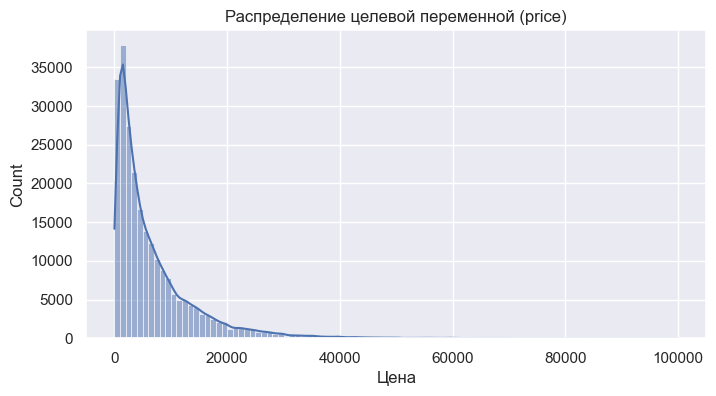

count    241190.000000
mean       6887.741892
std        8024.451993
min           1.000000
25%        1750.000000
50%        4100.000000
75%        8999.000000
max       99999.000000
Name: price, dtype: float64


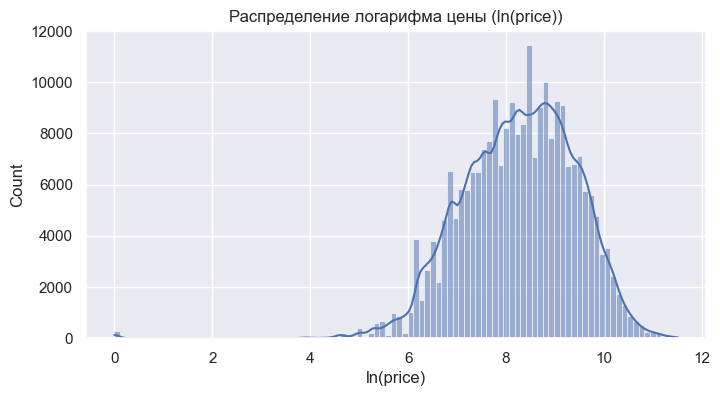

In [43]:
from descents import (
    ConstantLR, TimeDecayLR,
    VanillaGradientDescent, StochasticGradientDescent,
    MomentumDescent, Adam, SAGDescent
)
from linear_regression import LinearRegression

sns.set(style='darkgrid')

data = pd.read_csv('autos.csv')

plt.figure(figsize=(8, 4))
sns.histplot(data['price'], bins=100, kde=True)
plt.title('Распределение целевой переменной (price)')
plt.xlabel('Цена')
plt.show()

print(data['price'].describe())

price_log = np.log(data[data['price'] > 0]['price'])
plt.figure(figsize=(8, 4))
sns.histplot(price_log, bins=100, kde=True)
plt.title('Распределение логарифма цены (ln(price))')
plt.xlabel('ln(price)')
plt.ylabel('Count')
plt.show()

Для распределения цены наблюдается правосторонняя асимметрия, в то вермя как распределение логарифма цены похоже на нормальное. Очевидно, целевую переменную стоит заменить на логарифм, так как MSE лучше оценивает ошибки при нормальном распределении зависимой переменной.

В данных, конечно, есть выбросы, удаляем по 1.5iqr, немного схалтурив и укоротив мыслительный процесс...:

Количество выбросов по логарифму цены: 1156


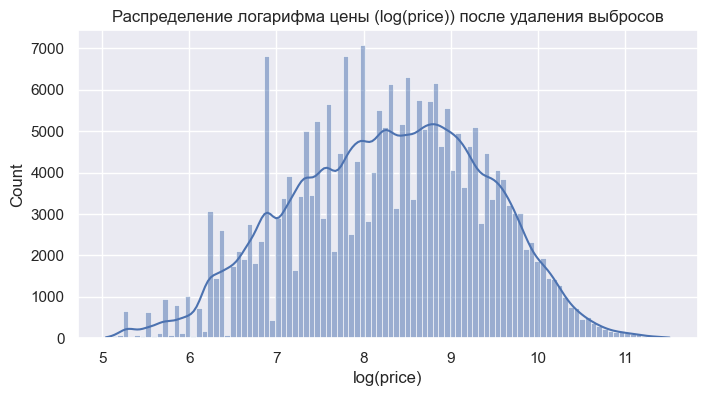

In [46]:
data = data[data['price'] > 0].copy()
data['price_log'] = np.log(data['price'])

Q1, Q3 = data['price_log'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data['price_log'] < lower_bound) | (data['price_log'] > upper_bound)]
print(f"Количество выбросов по логарифму цены: {len(outliers)}")

data_clean = data[(data['price_log'] >= lower_bound) & (data['price_log'] <= upper_bound)].copy()

plt.figure(figsize=(8, 4))
sns.histplot(data_clean['price_log'], bins=100, kde=True)
plt.title('Распределение логарифма цены (log(price)) после удаления выбросов')
plt.xlabel('log(price)')
plt.ylabel('Count')
plt.show()

Разделим признаки на категориальные, числовые и все остальное

In [48]:
categorical = [col for col in data_clean.columns if data_clean[col].dtype == 'object' or str(data_clean[col].dtype) == 'category']
numeric = [col for col in data_clean.columns if np.issubdtype(data_clean[col].dtype, np.number)]
other = [col for col in data_clean.columns if col not in categorical + numeric]

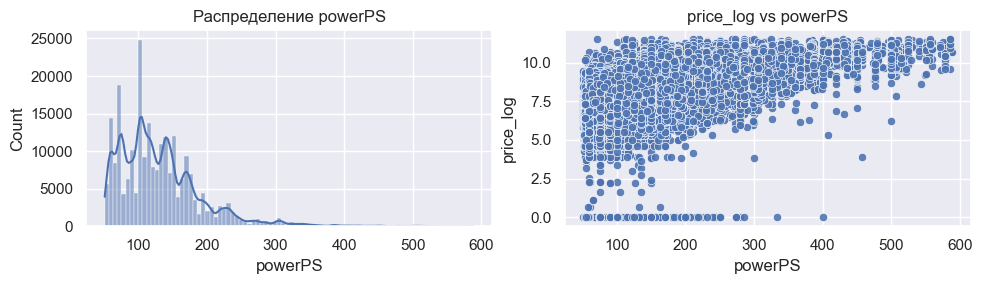

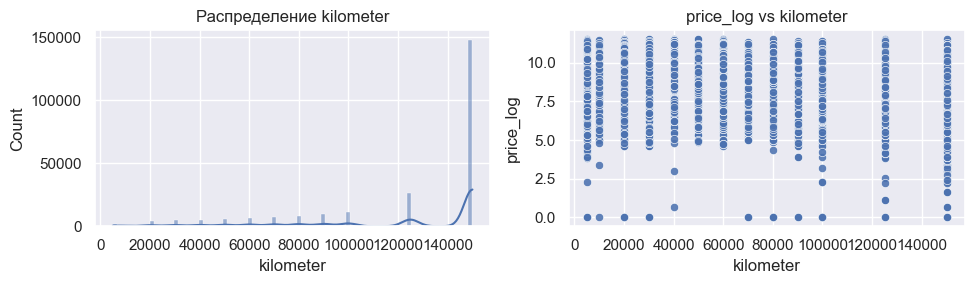

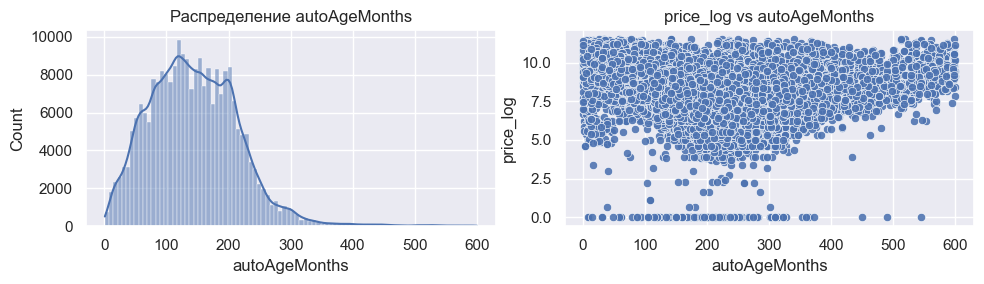

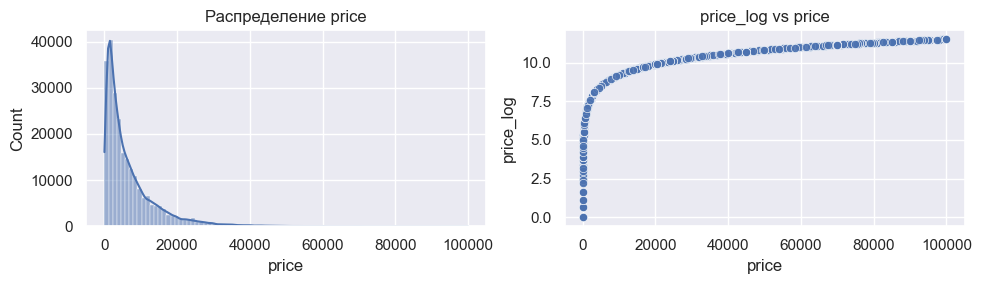

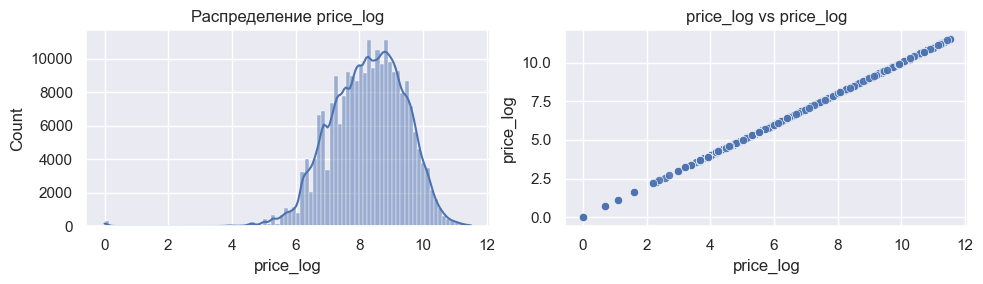

In [49]:
target = "price_log"

for col in numeric:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    sns.histplot(data[col], bins=88, kde=True, ax=axes[0])
    axes[0].set_title(f"Распределение {col}")

    sns.scatterplot(x=data[col], y=data[target], alpha=0.88, ax=axes[1])
    axes[1].set_title(f"{target} vs {col}")

    plt.tight_layout()
    plt.show()


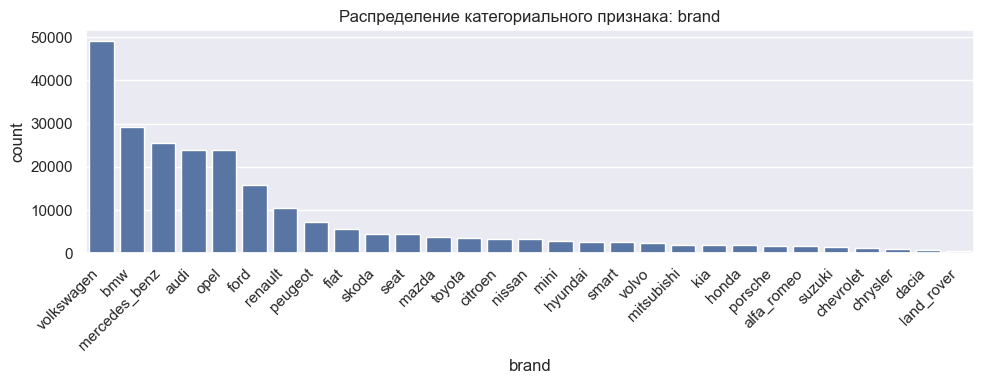

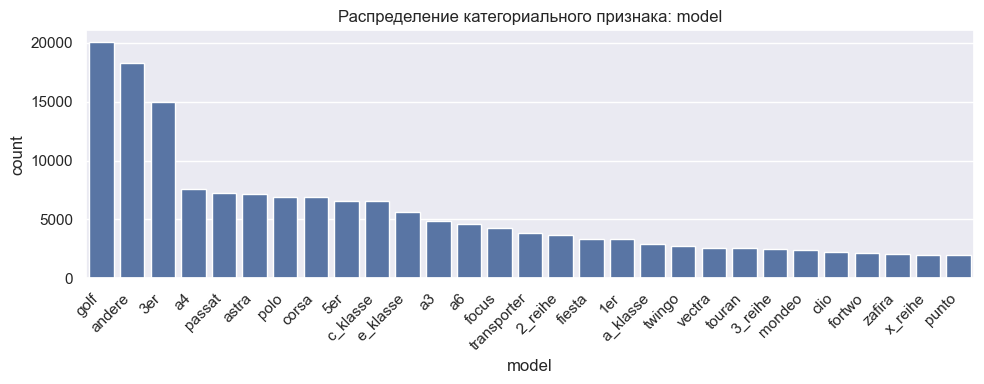

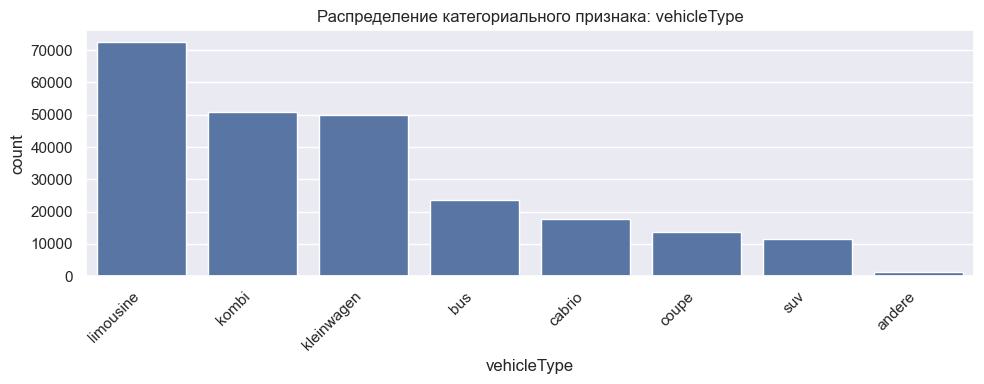

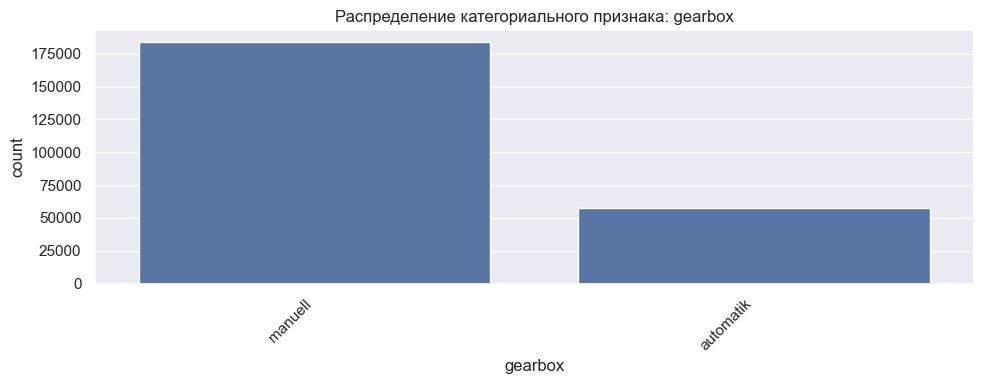

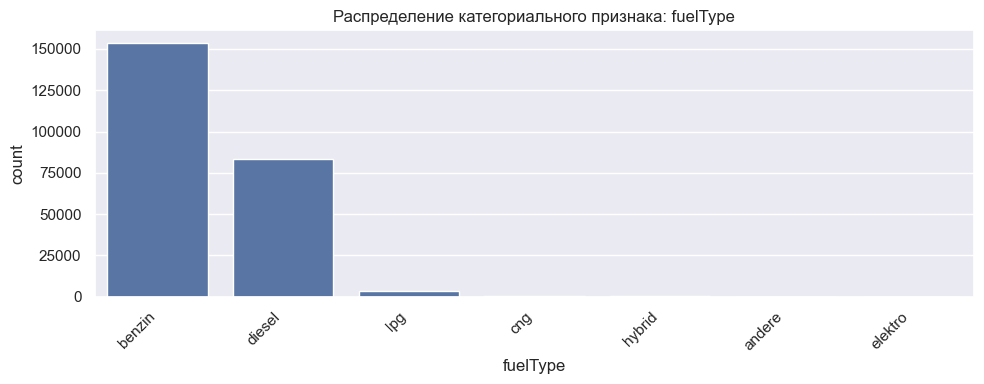

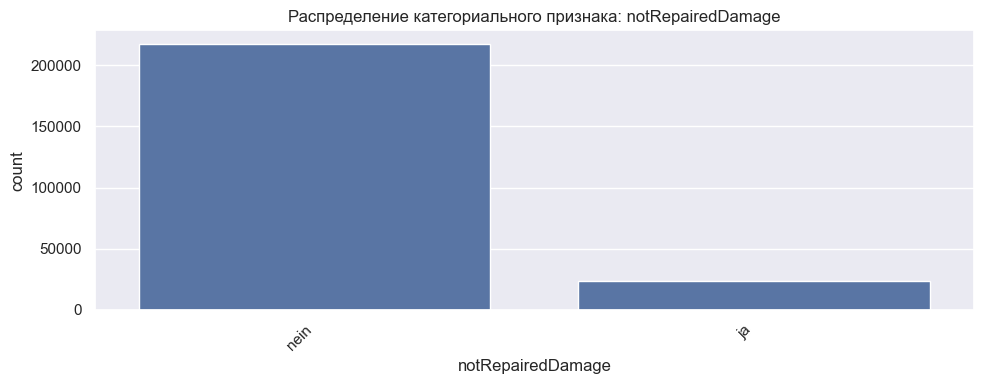

In [50]:
for col in categorical:
    plt.figure(figsize=(10, 4))
    order = data[col].value_counts().index[:29]  
    sns.countplot(data=data[data[col].isin(order)], x=col, order=order)
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Распределение категориального признака: {col}")
    plt.tight_layout()
    plt.show()

1. Какие признаки могут быть полезными: все признаки могут быть полезными за исключением, наверное, признака "model", ведь в нем слишком много значений (можно, конечно, укоротить), тем не менее остальное - это целевая переменная и признаки, интуитивно влияющие на цену машины, с относительно хорошими распределениями. 
2. Какие трансформации признаков уместно применить: 
    - price: логарифм цены
    - powerPS: корень
    - kilometer: MinMaxScaler или StandardScaler
    - autoAgeMonths: StandardScaler
    - brand, vehicleType, gearbox: pd.get_dummies()

Добавляем в данные единичную колонку `bias`, чтобы не делать отдельные параметр $b$ для свободного члена модели.

In [53]:
data['bias'] = 1
other += ['bias']

x = data[categorical + numeric + other]
y = data['price']

А также сделаем базовую обработку данных, а именно:
* Применим `OneHotEncoding` к категориальным признакам
* Стандартизуем численные признаки с помощью `StandardScaler`
* Остальные признаки трогать не будем, т.к. с ними непонятно что делать

In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler


column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('scaling', StandardScaler(), numeric),
    ('other',  'passthrough', other)
])

x = column_transformer.fit_transform(x)

Теперь необходимо разбить данные на обучающую, тестовую и валидационную выборки:

In [57]:
from sklearn.model_selection import train_test_split

x_train_val, x_test, y_train_val, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

x_train, x_val, y_train, y_val = train_test_split(
    x_train_val, y_train_val, test_size=1/9, random_state=42
)


## 5. Сравнение методов градиентного спуска

Сравним методы градиентного спуска на подготовленных данных из предыдущего раздела.

### 5.1. Подбор оптимальной длины шага 

Подберем по валидационной выборке наилучшую длину шага $\lambda$ для каждого метода с точки зрения ошибки. Для этого сделаем перебор по логарифмической сетке. Для каждого метода посчитаем ошибку на обучающей и тестовой выборках, посчитаем качество по метрике $R^2$ и сохраним количество итераций до сходимости.

Все параметры кроме `lambda_` выставим равным значениям по умолчанию.

In [60]:
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(100)
methods = {
    "Vanilla": VanillaGradientDescent,
    "SGD": StochasticGradientDescent,
    "SAG": SAGDescent,
    "Momentum": MomentumDescent,
    "Adam": Adam
}

lambdas = np.logspace(-2, 0, 6) 
results = []

y_train = y_train.to_numpy() if hasattr(y_train, "to_numpy") else y_train
y_val = y_val.to_numpy() if hasattr(y_val, "to_numpy") else y_val

def safe_train(model, x_train, y_train, x_val, y_val):    
        model.fit(x_train, y_train)
        y_pred_train = model.predict(x_train)
        y_pred_val = model.predict(x_val)

        return (
            mean_squared_error(y_train, y_pred_train),
            mean_squared_error(y_val, y_pred_val),
            r2_score(y_train, y_pred_train),
            r2_score(y_val, y_pred_val),
            len(model.loss_history)
)


for name, Method in methods.items():
    for lambda_ in lambdas:
        lr_schedule = lambda: TimeDecayLR(lambda_=lambda_)
        opt = Method(lr_schedule=lr_schedule)
        model = LinearRegression(optimizer=opt, max_iter=300, tolerance=1e-6)

        train_mse, val_mse, train_r2, val_r2, iters = safe_train(model, x_train, y_train, x_val, y_val)

        results.append({
            "method": name,
            "lambda": lambda_,
            "train_mse": train_mse,
            "val_mse": val_mse,
            "train_r2": train_r2,
            "val_r2": val_r2,
            "iterations": iters
        })

results_df = pd.DataFrame(results)
best_idx = results_df.groupby("method")["val_mse"].idxmin().dropna()
best = results_df.loc[best_idx]

print("\n Лучшие λ по валидации ")
print(best[["method", "lambda", "val_mse", "val_r2"]])


 Лучшие λ по валидации 
      method    lambda       val_mse    val_r2
29      Adam  1.000000  1.092855e+08 -0.662301
23  Momentum  1.000000  1.758901e+02  0.999997
17       SAG  1.000000  9.374384e+07 -0.425902
9        SGD  0.158489  1.774736e+06  0.973005
5    Vanilla  1.000000  4.498703e+03  0.999932


### 5.2. Сравнение методов 

Построим график зависимости ошибки на обучающей выборке от номера итерации (все методы на одном графике будут).

Сравним методы между собой.

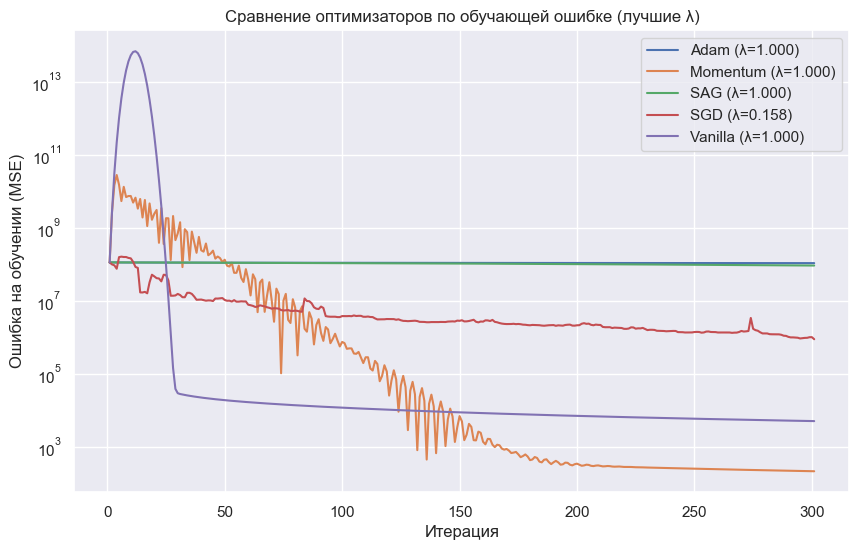

In [62]:
plt.figure(figsize=(10,6))

for _, row in best.iterrows():
    name = row["method"]
    lambda_ = row["lambda"]
    
    lr_schedule = lambda: TimeDecayLR(lambda_=lambda_)
    Method = methods[name]
    opt = Method(lr_schedule=lr_schedule)
    
    model = LinearRegression(optimizer=opt, max_iter=300, tolerance=1e-6)
    model.fit(x_train, y_train)
    
    plt.plot(range(1, len(model.loss_history)+1), model.loss_history, label=f"{name} (λ={lambda_:.3f})")

plt.xlabel("Итерация")
plt.ylabel("Ошибка на обучении (MSE)")
plt.title("Сравнение оптимизаторов по обучающей ошибке (лучшие λ)")
plt.yscale("log")  
plt.legend()
plt.grid(True)
plt.show()

Adam и SAG в данной конфигурации гиперпараметров обучаются слабее остальных.

Vanilla показывает самое быстрое уменьшение ошибки (но не самое большое) необычной траекторией.

Momentum снижает ошибку с высокой волатильностью, но показывает лучший итоговый результат.

## 6. Стохастический градиентный спуск и размер батча 

Исследуем влияние размера батча на работу стохастического градиентного спуска.

* Сделаем по несколько запусков ($k$) стохастического градиентного спуска на обучающей выборке для каждого размера батча из перебираемого списка. Замерим время в секундах и количество итераций до сходимости. Посчитаем среднее этих значений для каждого размера батча.
* Построим график зависимости количества шагов до сходимости от размера батча. _(под сходимостью понимается достижение критерия останова)_
* Построим график зависимости времени до сходимости от размера батча.

Посмотрим на получившиеся результаты. Сделаем выводы про подбор размера батча для стохастического градиентного спуска.

Batch 1: avg iterations = 4142.2, avg time = 13.020s
Batch 8: avg iterations = 5000.0, avg time = 15.244s
Batch 16: avg iterations = 5000.0, avg time = 15.278s
Batch 32: avg iterations = 5000.0, avg time = 15.302s
Batch 64: avg iterations = 5000.0, avg time = 15.536s
Batch 128: avg iterations = 5000.0, avg time = 15.365s


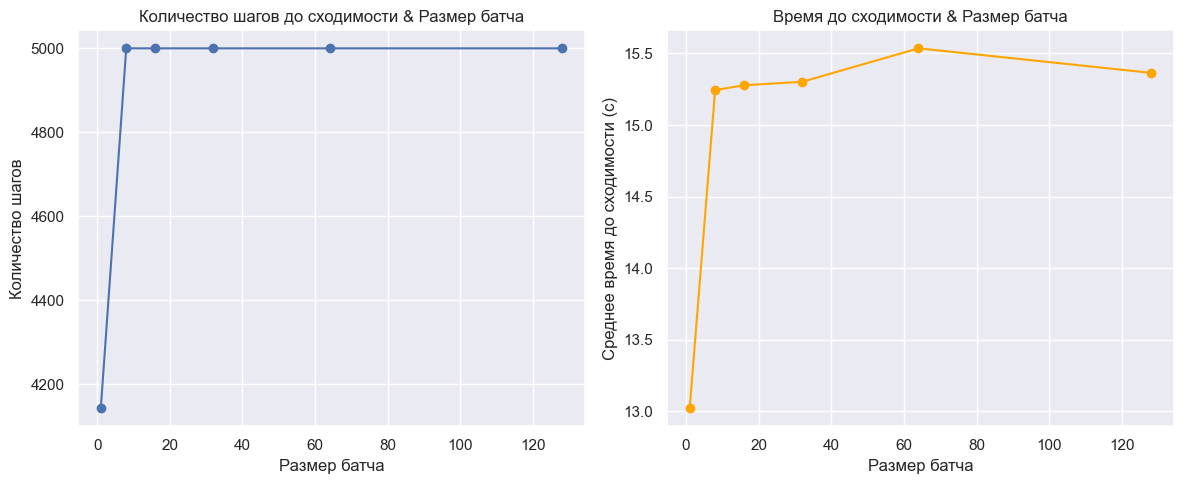

In [65]:
import time

best_lambda = 0.158
batch_sizes = [1, 8, 16, 32, 64, 128]
k_runs = 10
max_iter = 5000
tolerance = 1e-6
np.random.seed(88)
y_train_np = y_train.to_numpy() if hasattr(y_train, "to_numpy") else y_train

avg_iterations, avg_times = [], []

for batch in batch_sizes:
    iters_list, times_list = [], []
    
    for run in range(k_runs):
        lr_schedule = lambda: TimeDecayLR(lambda_=best_lambda)
        optimizer = StochasticGradientDescent(lr_schedule=lr_schedule, batch_size=batch)
        model = LinearRegression(optimizer=optimizer, tolerance=tolerance, max_iter=max_iter)
        optimizer.set_model(model)
        
        model.w = np.zeros(x_train.shape[1])
        model.X_train, model.y_train = x_train, y_train_np
        start_time = time.time() 
        model.loss_history = []
        for i in range(max_iter):
            w_prev = model.w.copy()
            delta_w = optimizer.update_weights()
            optimizer.iteration += 1
            if np.any(np.isnan(model.w)):
                break
            if np.linalg.norm(model.w - w_prev)**2 < tolerance:
                break
            if np.linalg.norm(delta_w)**2 < tolerance:

                break

            model.loss_history.append(model.compute_loss(x_train, y_train_np))

        elapsed = time.time() - start_time
        iters_list.append(i + 1)
        times_list.append(elapsed)
    
    avg_iterations.append(np.mean(iters_list))
    avg_times.append(np.mean(times_list))
    print(f"Batch {batch}: avg iterations = {avg_iterations[-1]:.1f}, avg time = {avg_times[-1]:.3f}s")

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(batch_sizes, avg_iterations, marker='o')
plt.xlabel("Размер батча")
plt.ylabel("Количество шагов")
plt.title("Количество шагов до сходимости & Размер батча")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(batch_sizes, avg_times, marker='o', color='orange')
plt.xlabel("Размер батча")
plt.ylabel("Среднее время до сходимости (с)")
plt.title("Время до сходимости & Размер батча")
plt.grid(True)

plt.tight_layout()
plt.show()

**Выводы:**

Для sgd следует батч выбирать так, чтобы он не был слишком маленьким (высокая дисперсия градиента и, как следствие, больше шума в данных) и не был слишком большим (больше вычислений и, как следствие, дольше сходится). Применительно к нашим данным я понял, что оптимальный размер батча должен быть от 20 до 60)

## 7. Регуляризация

Исследуем влияние регуляризации на работу различных методов градиентного спуска. Напоминание, регуляризация – это добавка к функции потерь, которая штрафует за норму весов. Я буду использовать $L_2$-регуляризацию, таким образом функция потерь приобретает следующий вид:

$$
    Q(w) = \dfrac{1}{\ell} \sum\limits_{i=1}^{\ell} (a_w(x_i) - y_i)^2 + \dfrac{\mu}{2} \| w \|^2
$$

Найдем лучшие параметры обучения с регуляризацией аналогично 5 заданию. Будем подбирать длину шага $\lambda$ (`lambda_`) и коэффициент регуляризации $\mu$ (`mu`).

Сравним для каждого метода результаты с регуляризацией и без регуляризации (нужно опять сохранить ошибку и качество по метрике $R^2$ на обучающей и тестовой выборках и количество итераций до сходимости).

Построим для каждого метода график со значениями функции потерь MSE с регуляризацией и без регуляризации (всего 5 графиков).

Посмотрим на получившиеся результаты. Сделаем выводы, как регуляризация влияет на сходимость; как меняется качество на обучающей выборке, на тестовой.


Лучшие параметры по MSE
       method  regularized    lambda      mu       val_mse    val_r2  \
179      Adam        False  1.000000  0.0000  1.092855e+08 -0.662301   
145      Adam         True  1.000000  0.0001  1.092855e+08 -0.662301   
173  Momentum        False  1.000000  0.0000  1.758901e+02  0.999997   
115  Momentum         True  1.000000  0.0001  1.758901e+02  0.999997   
167       SAG        False  1.000000  0.0000  9.607853e+07 -0.461414   
88        SAG         True  1.000000  0.1000  8.577139e+07 -0.304636   
159       SGD        False  0.158489  0.0000  1.526699e+06  0.976778   
48        SGD         True  0.158489  0.1000  1.682141e+06  0.974414   
155   Vanilla        False  1.000000  0.0000  4.498703e+03  0.999932   
25    Vanilla         True  1.000000  0.0001  4.498703e+03  0.999932   

        train_mse  train_r2  iterations  
179  1.065452e+08 -0.659164         301  
145  1.065452e+08 -0.659164         301  
173  2.102800e+02  0.999997         301  
115  2.102800e

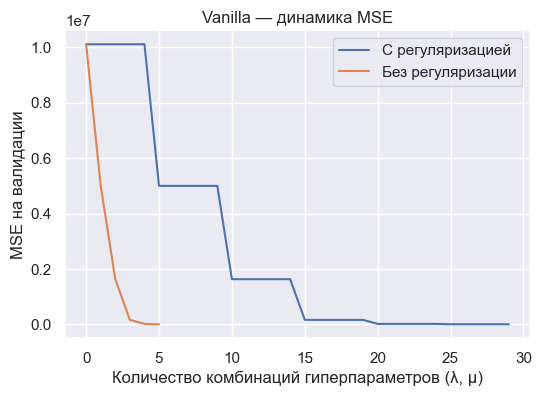

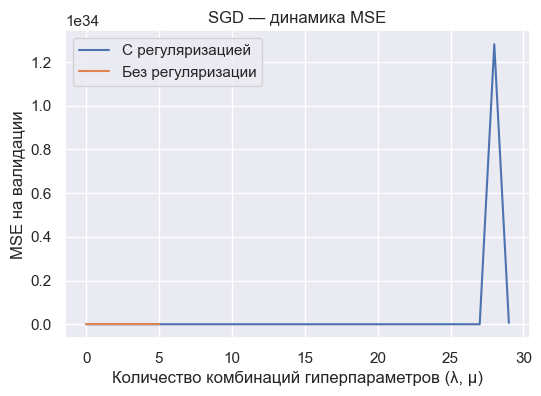

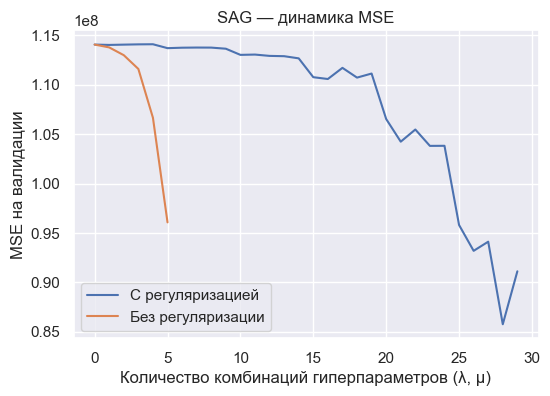

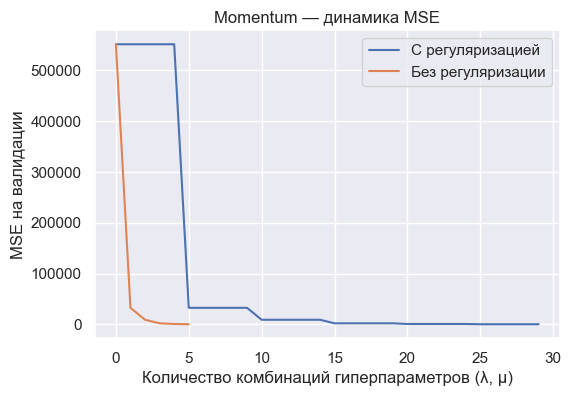

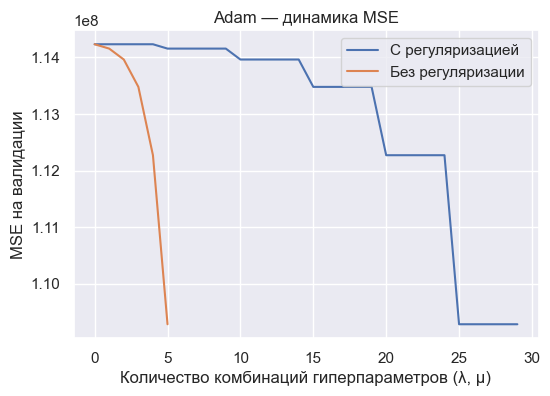

In [69]:
np.random.seed(100)

methods = {
    "Vanilla": VanillaGradientDescent,
    "SGD": StochasticGradientDescent,
    "SAG": SAGDescent,
    "Momentum": MomentumDescent,
    "Adam": Adam
}


lambdas = np.logspace(-2, 0, 6)   
mus = np.logspace(-4, 0, 5)    

results = []

y_train = y_train.to_numpy() if hasattr(y_train, "to_numpy") else y_train
y_val = y_val.to_numpy() if hasattr(y_val, "to_numpy") else y_val

def safe_train(model, x_train, y_train, x_val, y_val):    
    model.fit(x_train, y_train)
    y_pred_train = model.predict(x_train)
    y_pred_val = model.predict(x_val)

    return (
        mean_squared_error(y_train, y_pred_train),
        mean_squared_error(y_val, y_pred_val),
        r2_score(y_train, y_pred_train),
        r2_score(y_val, y_pred_val),
        len(model.loss_history)
    )

for name, Method in methods.items():
    for lambda_ in lambdas:
        for mu in mus:
            lr_schedule = lambda: TimeDecayLR(lambda_=lambda_)
            opt = Method(lr_schedule=lr_schedule)
            model = LinearRegression(
                optimizer=opt,
                l2_coef=mu,           
                max_iter=300,
                tolerance=1e-6
            )

            train_mse, val_mse, train_r2, val_r2, iters = safe_train(model, x_train, y_train, x_val, y_val)

            results.append({
                "method": name,
                "lambda": lambda_,
                "mu": mu,
                "train_mse": train_mse,
                "val_mse": val_mse,
                "train_r2": train_r2,
                "val_r2": val_r2,
                "iterations": iters,
                "regularized": True
            })

for name, Method in methods.items():
    for lambda_ in lambdas:
        lr_schedule = lambda: TimeDecayLR(lambda_=lambda_)
        opt = Method(lr_schedule=lr_schedule)
        model = LinearRegression(
            optimizer=opt,
            l2_coef=0.0,           
            max_iter=300,
            tolerance=1e-6
        )

        train_mse, val_mse, train_r2, val_r2, iters = safe_train(model, x_train, y_train, x_val, y_val)

        results.append({
            "method": name,
            "lambda": lambda_,
            "mu": 0.0,
            "train_mse": train_mse,
            "val_mse": val_mse,
            "train_r2": train_r2,
            "val_r2": val_r2,
            "iterations": iters,
            "regularized": False
        })

results_df = pd.DataFrame(results)

best_idx = results_df.groupby(["method", "regularized"])["val_mse"].idxmin().dropna()
best = results_df.loc[best_idx]

print("\nЛучшие параметры по MSE")
print(best[["method", "regularized", "lambda", "mu", "val_mse", "val_r2", "train_mse", "train_r2", "iterations"]])


for name in methods.keys():
    subset = results_df[results_df["method"] == name]
    reg = subset[subset["regularized"] == True]
    noreg = subset[subset["regularized"] == False]

    plt.figure(figsize=(6, 4))
    plt.plot(reg["val_mse"].values, label="С регуляризацией")
    plt.plot(noreg["val_mse"].values, label="Без регуляризации")
    plt.title(f"{name} — динамика MSE")
    plt.ylabel("MSE на валидации")
    plt.xlabel("Количество комбинаций гиперпараметров (λ, μ)")
    plt.legend()
    plt.grid(True)
    plt.show()


**Вывод:**

`- как регуляризация влияет на сходимость? - замедляет сходимость, но само обучение проходит более стабильно `

`- как изменилось качество на обучающей выборке? - "ухудшилось" (обычно mse растет, а коэффициент детерминации падает)`

`- как изменилось качество на тестовой выборке? - "улучшилось": зачастую регуляризация уменшает среднеквадратичную ошибку -> улучшает обобщающую способность -> снижает шанс переобучения`

`- Так происходит поскольку теперь модель минимизирует также и веса, делая модель менее чувствительной к выбросам, однако увеличивая ошибки на обучении`

## 8. Альтернативные функции потерь 

Для нашей задачи регрессии можно использовать и другие функции потерь. Наиболее ходовыми обычно считаются **LogCosh** и **HuberLoss**:

$$
    L(y, a)
    =
    \log\left(\cosh(a - y)\right).
$$

$$
L_{\text{Huber}}(y, a) = \frac{1}{n} \sum_{i=1}^{n}
\begin{cases}
   \frac{1}{2} (a_i - y_i)^2, & \text{если } |a_i - y_i| < \delta, \\
   \delta \cdot |a_i - y_i| - \frac{1}{2} \delta^2, & \text{если } |a_i - y_i| \geq \delta,
\end{cases}
$$

Продифференцируем данные функции потерь, чтобы понять как выглядят их градиенты:

**Решение:**

**Функция потерь:**

$$
L(y, a) = \log(\cosh(a - y))
$$

**Первая производная по a:**

$$
\frac{\partial L(y, a)}{\partial a} 
= \frac{\partial}{\partial a} \log(\cosh(a - y))
$$

$$
= \frac{1}{\cosh(a - y)} \cdot \frac{\partial}{\partial a}[\cosh(a - y)]
$$

$$
= \frac{1}{\cosh(a - y)} \cdot \sinh(a - y)
$$

$$
\Rightarrow \frac{\partial L(y, a)}{\partial a} = \tanh(a - y)
$$

**Если a = Xw , то градиент по весам:**

$$
\nabla_w L = X^\top \frac{\partial L}{\partial a}
$$

$$
\Rightarrow \nabla_w L_{\text{LogCosh}} = X^\top \tanh(Xw - y)
$$




**Функция потерь:**
$$
L_{\text{Huber}}(y, a) =
\begin{cases}
\frac{1}{2}(a - y)^2, & \text{если } |a - y| < \delta, \\
\delta |a - y| - \frac{1}{2}\delta^2, & \text{если } |a - y| \ge \delta
\end{cases}
$$

**Первая производная по a:**

$$
\frac{\partial L_{\text{Huber}}(y, a)}{\partial a} =
\begin{cases}
(a - y), & \text{если } |a - y| < \delta, \\
\delta \, \operatorname{sign}(a - y), & \text{если } |a - y| \ge \delta
\end{cases}
$$

**Если a = Xw , то градиент по весам:**

$$
\nabla_w L = X^\top \frac{\partial L}{\partial a}
$$

$$
\Rightarrow
\nabla_w L_{\text{Huber}} =
X^\top
\begin{cases}
(Xw - y), & \text{если } |Xw - y| < \delta, \\
\delta \, \operatorname{sign}(Xw - y), & \text{если } |Xw - y| \ge \delta
\end{cases}
$$


___



---

## Итоги

Momentum дал лучший итоговый результат, хотя траектория обучения у него самая волатильная. Vanilla быстрее всех снижает ошибку на первых итерациях, но останавливается на чуть худшем значении. Adam и SAG на этих данных и с этими гиперпараметрами отработали слабее остальных.

Для SGD размер батча имеет выраженный оптимум в средней зоне: слишком маленький батч даёт высокую дисперсию градиента и лишний шум, слишком большой — больше вычислений на итерацию и медленнее сходимость по времени.

L2-регуляризация ведёт себя ровно так, как предсказывает теория: сходимость замедляется, качество на обучении слегка падает, на тесте растёт. Классический bias-variance trade-off, воспроизведённый экспериментально.

Аналитическое решение через SVD работает там, где обычная нормальная система уравнений ломается — при полной мультиколлинеарности признаков матрица $X^\top X$ вырождена и обращению не поддаётся.
